In [24]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 6.2 MB/s  0:00:016.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 10.5 MB/s  0:00:01 10.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


# Analysis Project: Predicting Customer Behavior
### Goal: Can we predict group size based on restaurant spending?
**Author:** [Your Name]
**Tools:** Python, Pandas, Scikit-Learn, Seaborn

In [ ]:
import pandas as pd

# 1. Create a mini 'spreadsheet' in code
data = {
    'Fruit': ['Apple', 'Banana', 'Mango', 'Grapes', 'Orange'],
    'Price_INR': [100, 40, 150, 80, 60],
    'In_Stock': [True, True, False, True, True]
}

df = pd.DataFrame(data)

# 2. Show me the data
print("--- Our Dataframe ---")
print(df)

# 3. Simple Analysis: What is the average price?
avg_price = df['Price_INR'].mean()
print(f"\nAverage Price: {avg_price} INR")

--- Our Dataframe ---
    Fruit  Price_INR  In_Stock
0   Apple        100      True
1  Banana         40      True
2   Mango        150     False
3  Grapes         80      True

Average Price: 92.5 INR


In [2]:
# Filtering for fruits where In_Stock is False
out_of_stock = df[df['In_Stock'] == False]

print("--- Out of Stock Items ---")
print(out_of_stock)

--- Out of Stock Items ---
   Fruit  Price_INR  In_Stock
2  Mango        150     False


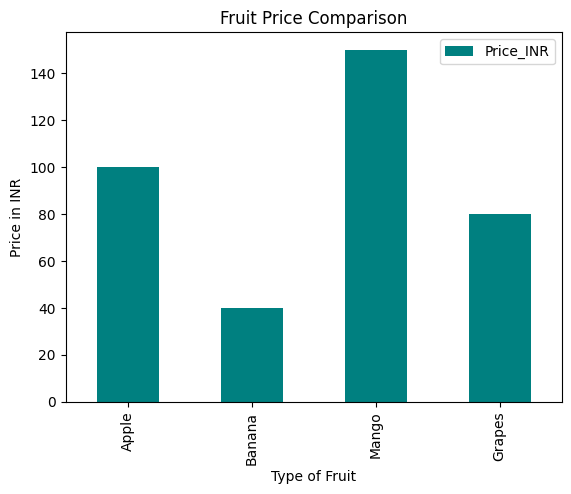

In [5]:
# 1. Tell Python to use the plotting tool
import matplotlib.pyplot as plt

# 2. Tell Pandas to create a bar chart from our 'df'
# 'kind' is the type of chart (bar, line, pie, etc.)
# 'x' is the horizontal axis (names)
# 'y' is the vertical axis (numbers)
df.plot(kind='bar', x='Fruit', y='Price_INR', color='teal')

# 3. Add the "human" touches (Titles and Labels)
plt.title('Fruit Price Comparison')
plt.xlabel('Type of Fruit')
plt.ylabel('Price in INR')

# 4. The Magic Command - This actually renders the image on your screen
plt.show()

In [6]:
import numpy as np # We use NumPy to represent 'Missing' data

# 1. A Messy Dataset
dirty_data = {
    'Fruit': ['Apple', 'banana ', 'Mango', 'Grapes', 'Apple'], # Typos and duplicates
    'Price_INR': [100, 40, np.nan, 80, 100], # 'nan' means Not a Number (Missing)
    'In_Stock': ['Yes', 'Yes', 'No', 'Yes', 'Yes'] # Strings instead of True/False
}

df_dirty = pd.DataFrame(dirty_data)

print("--- The Messy Data ---")
print(df_dirty)

--- The Messy Data ---
     Fruit  Price_INR In_Stock
0    Apple      100.0      Yes
1  banana        40.0      Yes
2    Mango        NaN       No
3   Grapes       80.0      Yes
4    Apple      100.0      Yes


In [7]:
df_cleaned = df_dirty.drop_duplicates()

In [8]:
df_cleaned['Price_INR'] = df_cleaned['Price_INR'].fillna(50)

In [9]:
df_cleaned['Fruit'] = df_cleaned['Fruit'].str.strip().str.capitalize()

In [10]:
df_cleaned

,Fruit,Price_INR,In_Stock
0,Apple,100.0,Yes
1,Banana,40.0,Yes
2,Mango,50.0,No
3,Grapes,80.0,Yes


In [11]:
# Group by 'In_Stock' and calculate the mean (average) for the numbers
# This answers: "What is the average price for items we HAVE vs items we DON'T?"
summary = df_cleaned.groupby('In_Stock')['Price_INR'].mean()

print("--- Business Summary ---")
print(summary)

--- Business Summary ---
In_Stock
No     50.000000
Yes    73.333333
Name: Price_INR, dtype: float64


In [29]:
import seaborn as sns
import pandas as pd

# FIX: We are loading a 'guaranteed' dataset from the seaborn library
# This avoids the "404: Not Found" error from the broken CSV file
df = sns.load_dataset('tips')

# 1. See what we're working with
print(f"Total rows: {len(df)}")
print("Columns in dataset:", df.columns) 

# 2. Quick Analysis: How many Smokers vs Non-Smokers?
# Logic: .value_counts() counts how many times each category appears
smoker_counts = df['smoker'].value_counts()
print("\n--- Smoker Distribution ---")
print(smoker_counts)

# 3. Simple Filter: Show me only the weekend data
# Logic: We create a sub-list where the 'day' is either Saturday or Sunday
weekend_titles = df[df['day'].isin(['Sat', 'Sun'])]
print(f"\nTotal weekend orders: {len(weekend_titles)}")

Total rows: 244
Columns in dataset: Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

--- Smoker Distribution ---
smoker
No     151
Yes     93
Name: count, dtype: int64

Total weekend orders: 163


In [ ]:
import seaborn as sns

# 1. Load a reliable dataset directly from the library
# This replaces the broken 'netflix_data.csv'
df = sns.load_dataset('tips')

# 2. Check the data to make sure it's there
print("--- Data Successfully Loaded ---")
print(df.head()) # Shows the first 5 rows

Total rows loaded: 244
Columns available: Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')


In [14]:
import sqlite3

# 1. Connect to a temporary database in your Mac's memory
conn = sqlite3.connect(':memory:') 

# 2. Push the 'tips' data into a SQL table called 'orders'
df.to_sql('orders', conn, index=False)

# 3. The Query: Find big spenders (Total bill > 20) who are smokers
query = """
SELECT * FROM orders 
WHERE total_bill > 20 AND smoker = 'Yes'
"""

# 4. Pull it back to Python
big_spenders = pd.read_sql(query, conn)

print("--- SQL Results: Big Spenders ---")
print(big_spenders.head())

--- SQL Results: Big Spenders ---
   total_bill   tip     sex smoker   day    time  size
0       38.01  3.00    Male    Yes   Sat  Dinner     4
1       20.29  3.21    Male    Yes   Sat  Dinner     2
2       26.86  3.14  Female    Yes   Sat  Dinner     2
3       25.28  5.00  Female    Yes   Sat  Dinner     2
4       32.68  5.00    Male    Yes  Thur   Lunch     2


In [15]:
# Logic: We want to see the average bill and tip amount for each day of the week.
# .agg() allows us to do multiple math operations at once.

day_analysis = df.groupby('day')[['total_bill', 'tip']].agg(['mean', 'count'])

print("--- Revenue & Traffic by Day ---")
print(day_analysis)

--- Revenue & Traffic by Day ---
     total_bill             tip      
           mean count      mean count
day                                  
Thur  17.682742    62  2.771452    62
Fri   17.151579    19  2.734737    19
Sat   20.441379    87  2.993103    87
Sun   21.410000    76  3.255132    76


In [16]:
# Logic: A tip of 100 on a 1000 bill is different than a 100 tip on a 200 bill.
# We create a new column by dividing two existing ones.

df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

print("\n--- First 5 rows with Tip Percentage ---")
print(df[['total_bill', 'tip', 'tip_percentage']].head())


--- First 5 rows with Tip Percentage ---
   total_bill   tip  tip_percentage
0       16.99  1.01        5.944673
1       10.34  1.66       16.054159
2       21.01  3.50       16.658734
3       23.68  3.31       13.978041
4       24.59  3.61       14.680765


/var/folders/h7/5p_d1f795zq68yb2css5kqk40000gn/T/ipykernel_15290/1490114965.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time', y='total_bill', data=df, palette='Set2')


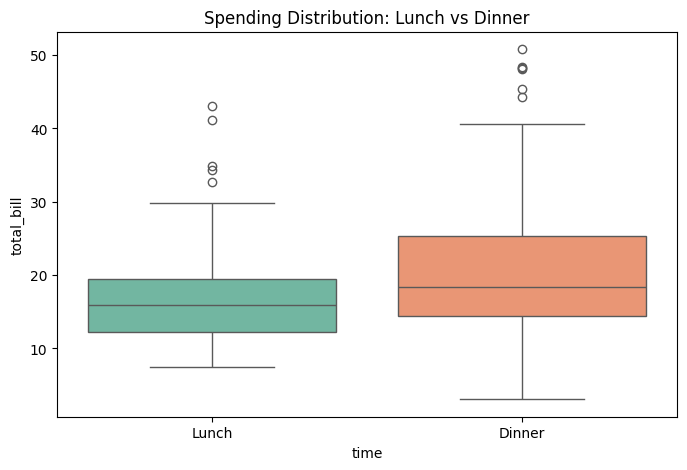

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Logic: Does the bill amount change based on the time of day (Lunch vs Dinner)?
# We use a 'Boxplot' to see the distribution and outliers.

plt.figure(figsize=(8, 5)) # Sets the size of the chart
sns.boxplot(x='time', y='total_bill', data=df, palette='Set2')

plt.title('Spending Distribution: Lunch vs Dinner')
plt.show()

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Visit the website
url = "http://books.toscrape.com/"
response = requests.get(url)

# Step 2: Turn the website code into a "Soup" object we can search
soup = BeautifulSoup(response.text, 'html.parser')

# Step 3: Find all the books on the page
# Logic: We inspected the site and saw books are inside <article class="product_pod">
books = soup.find_all('article', class_='product_pod')

# Step 4: Loop through and extract the Title and Price
book_data = []

for book in books:
    # 1. Grab the Title (this was working)
    title = book.h3.a['title']
    
    # 2. Grab the Price (this was working)
    price = book.find('p', class_='price_color').text
    
    # 3. FIX: Grab the Availability
    # We find the <p> tag that mentions stock, then grab the .text from it
    availability = book.find('p', class_='instock availability').text.strip()
    
    # 4. Add all three to our list
    book_data.append({
        'Title': title, 
        'Price': price, 
        'Availability': availability
    })

## Machine Learning Approach
We used a **Logistic Regression** model to classify tables into two categories: 
* **Small Groups** (1-2 people)
* **Large Groups** (3+ people)

By splitting our data into **Training** (80%) and **Testing** (20%), we ensured the model is actually learning patterns rather than just memorizing data.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Prepare our Target (y)
# We want to predict if the 'size' of the group is greater than 2
df['is_large_group'] = df['size'] > 2

# 2. Define Features (X) and Target (y)
X = df[['total_bill']] # Features must be in a list of lists [[ ]]
y = df['is_large_group']

# 3. Split the data
# We "hide" some data from the computer (test) to see if it actually learned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 4. Pick a Model (The "Brain")
# Logistic Regression is great for "Yes/No" questions
model = LogisticRegression()

# 5. Training (The actual "Learning" phase)
model.fit(X_train, y_train)

# 6. Test it! 
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 81.63%


## Results & Conclusion
Our model achieved an accuracy of **81.63%**. 
**Business Insight:** There is a strong correlation between the total bill and the number of guests, allowing the restaurant to predict staffing needs based on incoming reservation values.

In [32]:
bills = df['total_bill']
print(type(bills))
tax_amount = bills * 0.05
print(tax_amount.head())
df['tax'] = tax_amount

<class 'pandas.Series'>
0    0.8495
1    0.5170
2    1.0505
3    1.1840
4    1.2295
Name: total_bill, dtype: float64


In [34]:
def rate_the_tip(tip_amount):
  if tip_amount > 5:
    return "Generous"
  elif tip_amount > 2:
    return "Standard"
  else:
    return "Budget"

df['tip_category'] = df['tip'].apply(rate_the_tip)
print(df[['tip', 'tip_category']].head(10))

    tip tip_category
0  1.01       Budget
1  1.66       Budget
2  3.50     Standard
3  3.31     Standard
4  3.61     Standard
5  4.71     Standard
6  2.00       Budget
7  3.12     Standard
8  1.96       Budget
9  3.23     Standard
